# Notebook 5 — Image Quality Improvement & Model Refinement

This notebook focuses on improving the visual quality of the generative models developed in the previous phases.

The earlier notebooks primarily used a small synthetic dataset and short training runs for architectural validation. As a result, the generated images were structurally valid but visually noisy and low quality.

In this notebook we:
- train models using real WikiArt images
- increase training duration
- compare VAE, DCGAN, WGAN-GP, and CycleGAN quality
- evaluate generated images using FID and Inception Score
- visually compare generated samples
- save improved checkpoints
- generate a higher-quality portfolio

The objective is to improve actual image quality rather than simply increasing exported image resolution.

## 1. Environment Setup

In [37]:
%matplotlib inline

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from torch.optim import Adam

from generative_art_studio import config
from generative_art_studio.config import DEVICE
from generative_art_studio.utils import set_seed, plot_image_grid

set_seed(42)

print("Repository:", REPO_ROOT)
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available - using CPU")

Repository: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula
Device: cuda
PyTorch: 2.13.0+cu126
GPU: NVIDIA GeForce GTX 1660 Ti


## 2. Training Configuration

The previous experiments used only a few epochs. This notebook uses longer training runs on real WikiArt data.

If training takes too long, reduce the epoch values before starting.

In [38]:
SEED = 42
IMAGE_SIZE = 64
BATCH_SIZE = 32

VAE_EPOCHS = 30
GAN_EPOCHS = 30
DCGAN_EPOCHS = 50
WGAN_EPOCHS = 50
CYCLEGAN_EPOCHS = 50

VAE_LATENT_DIM = 128
GAN_LATENT_DIM = 64
DCGAN_LATENT_DIM = 100

LEARNING_RATE = 2e-4
BETAS = (0.5, 0.999)

CHECKPOINT_DIR = REPO_ROOT / "checkpoints"
QUALITY_OUTPUT_DIR = REPO_ROOT / "outputs" / "quality"
PORTFOLIO_DIR = REPO_ROOT / "outputs" / "portfolio_quality"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
QUALITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PORTFOLIO_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)
print("Portfolio directory:", PORTFOLIO_DIR)

Checkpoint directory: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints
Portfolio directory: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\outputs\portfolio_quality


## 3. Load the Real WikiArt Dataset

The unconditional models use all available WikiArt images. CycleGAN later separates the content and style domains.

In [39]:
from generative_art_studio.data import get_image_dataset, get_dataloader

wikiart_dataset = get_image_dataset(
    REPO_ROOT / "data" / "wikiart",
    image_size=IMAGE_SIZE,
)

full_dataloader = get_dataloader(
    wikiart_dataset,
    batch_size=BATCH_SIZE,
)

print("Dataset exists:", (REPO_ROOT / "data" / "wikiart").exists())
print("Dataset size:", len(wikiart_dataset))
print("Classes:", wikiart_dataset.classes)

real_images, real_labels = next(iter(full_dataloader))
print("Batch shape:", real_images.shape)
print("Label shape:", real_labels.shape)

Dataset exists: True
Dataset size: 10000
Classes: ['content', 'style']
Batch shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\src\generative_art_studio\utils\viz.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(nrow, nrow))


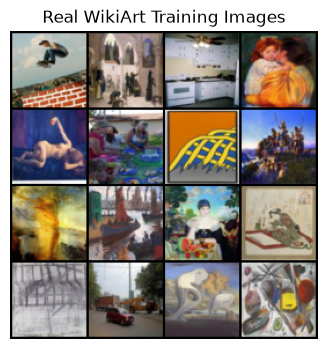

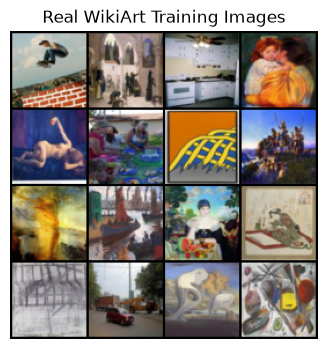

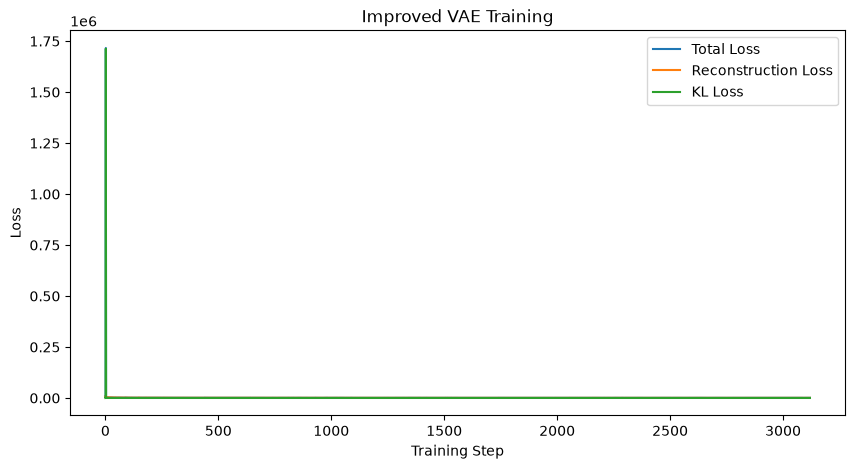

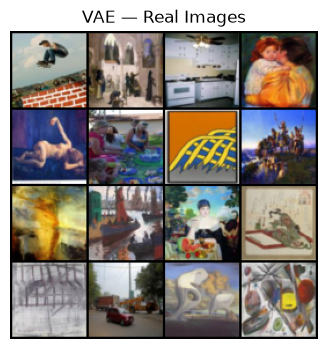

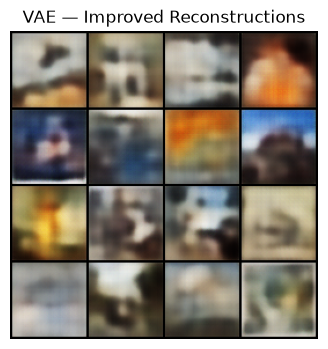

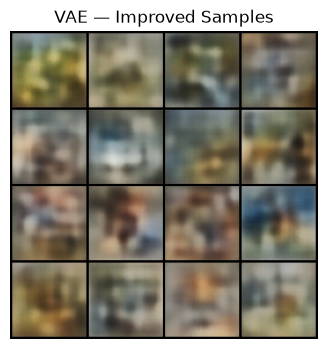

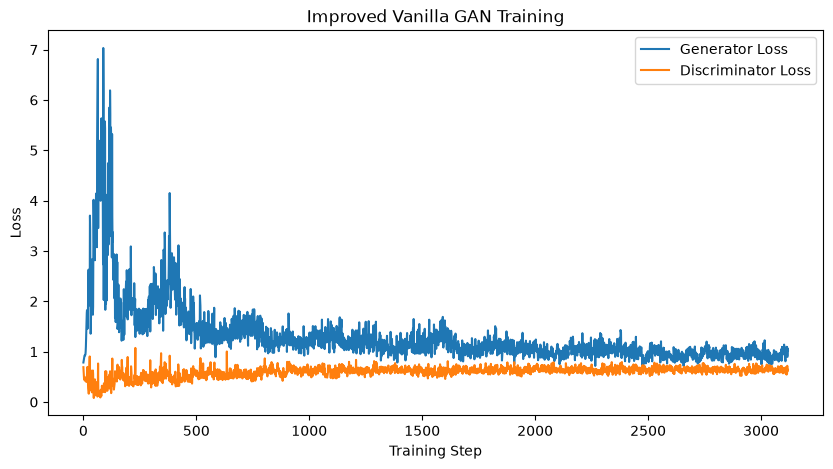

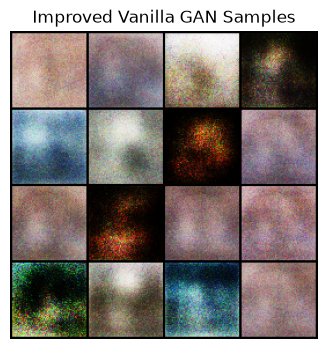

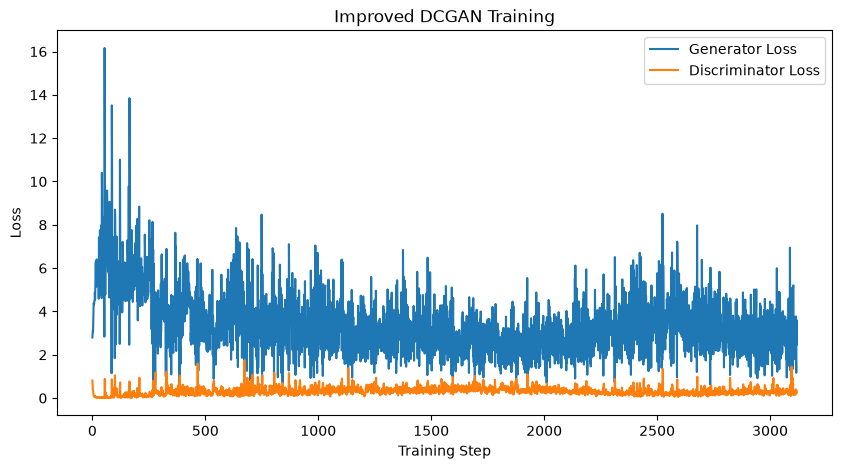

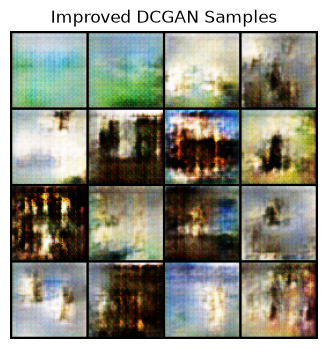

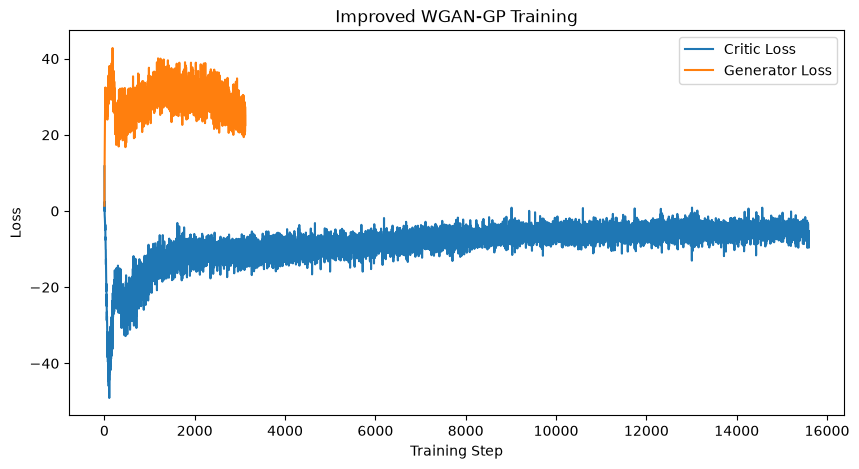

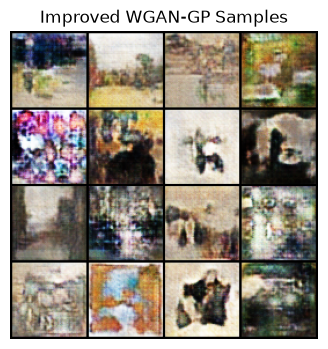

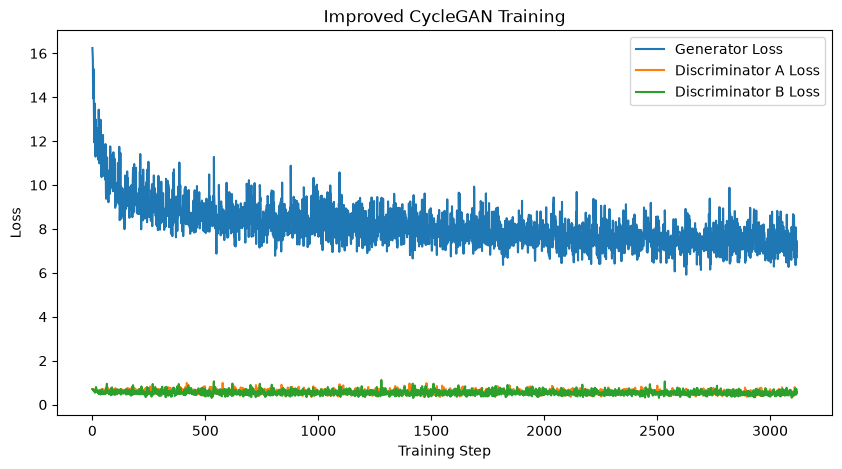

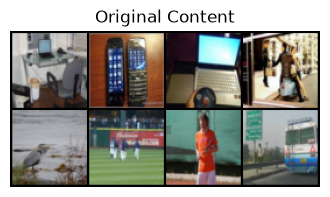

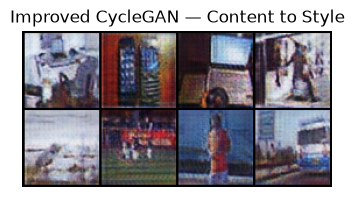

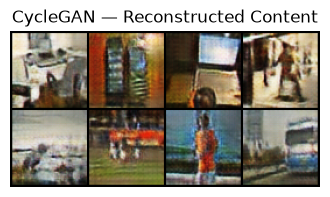

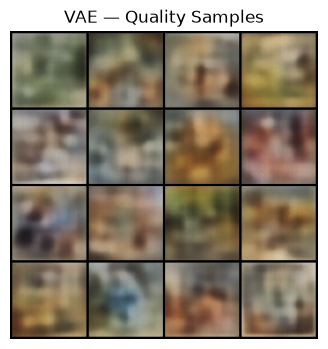

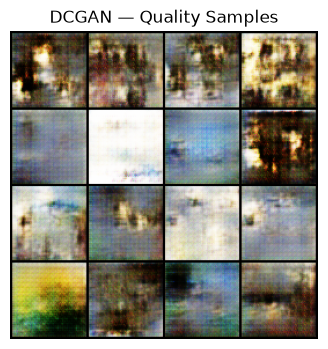

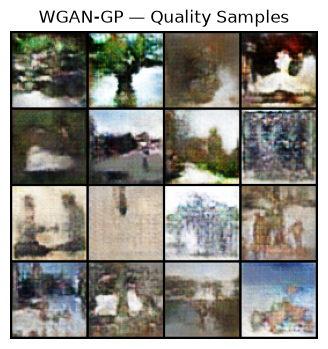

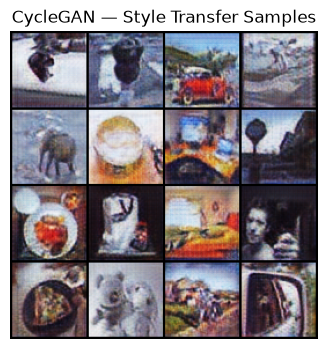

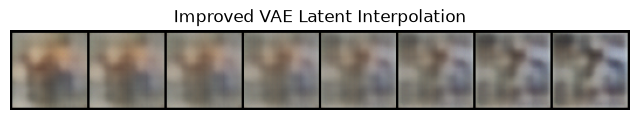

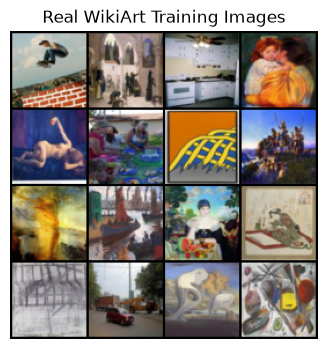

In [40]:
plot_image_grid(
    real_images[:16],
    nrow=4,
    title="Real WikiArt Training Images",
)

## 4. Create Separate CycleGAN Domains

In [41]:
from torch.utils.data import Subset

content_indices = [
    i for i, label in enumerate(wikiart_dataset.targets)
    if label == wikiart_dataset.class_to_idx["content"]
]

style_indices = [
    i for i, label in enumerate(wikiart_dataset.targets)
    if label == wikiart_dataset.class_to_idx["style"]
]

content_dataset = Subset(wikiart_dataset, content_indices)
style_dataset = Subset(wikiart_dataset, style_indices)

content_dataloader = get_dataloader(content_dataset, batch_size=16)
style_dataloader = get_dataloader(style_dataset, batch_size=16)

print("Content images:", len(content_dataset))
print("Style images:", len(style_dataset))

Content images: 5000
Style images: 5000


# Part A — Improved VAE

In [42]:
from generative_art_studio.models.autoencoders import VAE
from generative_art_studio.training.train_vae import train_vae

vae = VAE(
    in_channels=3,
    latent_dim=VAE_LATENT_DIM,
).to(DEVICE)

vae_optimizer = Adam(vae.parameters(), lr=1e-3)

vae_history = train_vae(
    vae,
    full_dataloader,
    vae_optimizer,
    device=DEVICE,
    epochs=VAE_EPOCHS,
    kl_weight=1.0,
)

print("VAE training complete.")

VAE epoch 1/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE epoch 2/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE epoch 3/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE epoch 4/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE epoch 5/30:   0%|          | 0/312 [00:00<?, ?it/s]

...

VAE epoch 27/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE epoch 28/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE epoch 29/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE epoch 30/30:   0%|          | 0/312 [00:00<?, ?it/s]

VAE training complete.


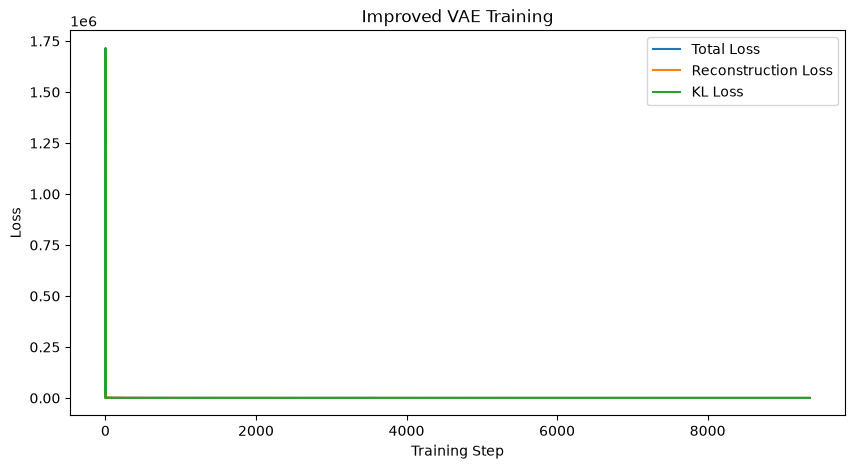

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(vae_history.total, label="Total Loss")
plt.plot(vae_history.recon, label="Reconstruction Loss")
plt.plot(vae_history.kl, label="KL Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Improved VAE Training")
plt.legend()
plt.show()

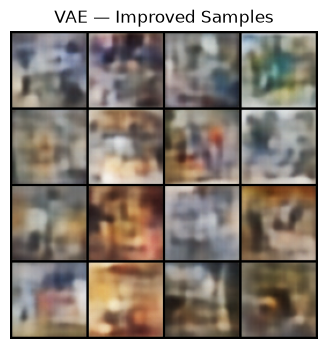

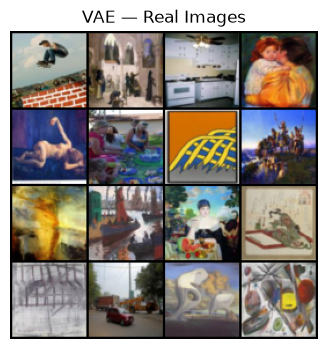

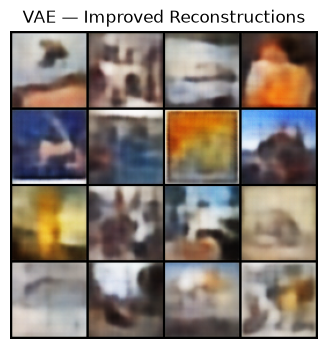

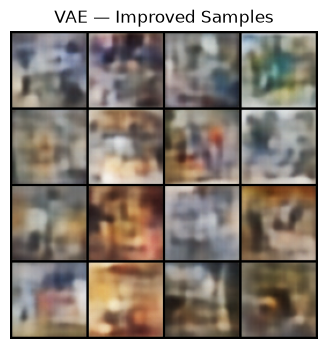

In [44]:
vae.eval()

with torch.no_grad():
    vae_recon, _, _ = vae(real_images.to(DEVICE))
    vae_samples = vae.sample(16, device=DEVICE)

plot_image_grid(real_images[:16], nrow=4, title="VAE — Real Images")
plot_image_grid(vae_recon[:16].cpu(), nrow=4, title="VAE — Improved Reconstructions")
plot_image_grid(vae_samples.cpu(), nrow=4, title="VAE — Improved Samples")

In [45]:
vae_checkpoint = CHECKPOINT_DIR / "vae_quality.pt"
torch.save(vae.state_dict(), vae_checkpoint)
print("Saved:", vae_checkpoint)

Saved: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints\vae_quality.pt


# Part B — Improved Vanilla GAN

In [46]:
from generative_art_studio.models.gans import VanillaGenerator, VanillaDiscriminator
from generative_art_studio.training.train_gan import train_gan

vanilla_g = VanillaGenerator(latent_dim=GAN_LATENT_DIM).to(DEVICE)
vanilla_d = VanillaDiscriminator().to(DEVICE)

vanilla_g_optimizer = Adam(vanilla_g.parameters(), lr=LEARNING_RATE, betas=BETAS)
vanilla_d_optimizer = Adam(vanilla_d.parameters(), lr=LEARNING_RATE, betas=BETAS)

vanilla_history = train_gan(
    vanilla_g,
    vanilla_d,
    full_dataloader,
    vanilla_g_optimizer,
    vanilla_d_optimizer,
    GAN_LATENT_DIM,
    device=DEVICE,
    epochs=GAN_EPOCHS,
)

print("Vanilla GAN training complete.")

GAN epoch 1/30:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 2/30:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 3/30:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 4/30:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 5/30:   0%|          | 0/312 [00:00<?, ?it/s]

...

GAN epoch 27/30:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 28/30:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 29/30:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 30/30:   0%|          | 0/312 [00:00<?, ?it/s]

Vanilla GAN training complete.


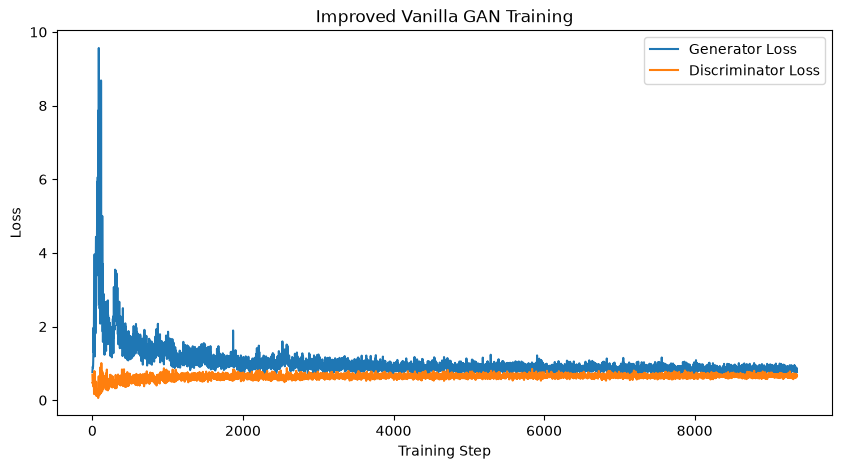

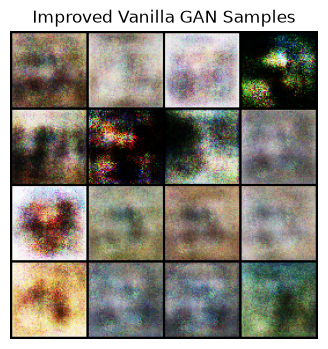

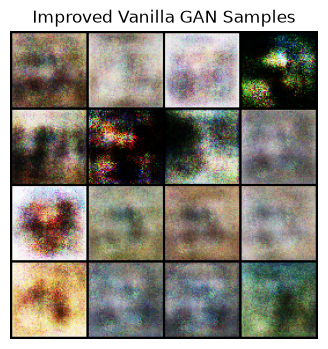

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(vanilla_history.g_loss, label="Generator Loss")
plt.plot(vanilla_history.d_loss, label="Discriminator Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Improved Vanilla GAN Training")
plt.legend()
plt.show()

vanilla_g.eval()
z = torch.randn(16, GAN_LATENT_DIM, device=DEVICE)
with torch.no_grad():
    vanilla_samples = vanilla_g(z)

plot_image_grid(vanilla_samples.cpu(), nrow=4, title="Improved Vanilla GAN Samples")

In [48]:
vanilla_checkpoint = CHECKPOINT_DIR / "vanilla_gan_quality.pt"
torch.save(vanilla_g.state_dict(), vanilla_checkpoint)
print("Saved:", vanilla_checkpoint)

Saved: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints\vanilla_gan_quality.pt


# Part C — Improved DCGAN

In [49]:
from generative_art_studio.models.gans import (
    DCGANGenerator,
    DCGANDiscriminator,
    weights_init_dcgan,
)

dc_generator = DCGANGenerator(
    latent_dim=DCGAN_LATENT_DIM,
    feature_maps=32,
).to(DEVICE)

dc_discriminator = DCGANDiscriminator(
    feature_maps=32,
).to(DEVICE)

dc_generator.apply(weights_init_dcgan)
dc_discriminator.apply(weights_init_dcgan)

dc_g_optimizer = Adam(dc_generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
dc_d_optimizer = Adam(dc_discriminator.parameters(), lr=LEARNING_RATE, betas=BETAS)

dc_history = train_gan(
    dc_generator,
    dc_discriminator,
    full_dataloader,
    dc_g_optimizer,
    dc_d_optimizer,
    DCGAN_LATENT_DIM,
    device=DEVICE,
    epochs=DCGAN_EPOCHS,
)

print("DCGAN training complete.")

GAN epoch 1/50:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 2/50:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 3/50:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 4/50:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 5/50:   0%|          | 0/312 [00:00<?, ?it/s]

...

GAN epoch 47/50:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 48/50:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 49/50:   0%|          | 0/312 [00:00<?, ?it/s]

GAN epoch 50/50:   0%|          | 0/312 [00:00<?, ?it/s]

DCGAN training complete.


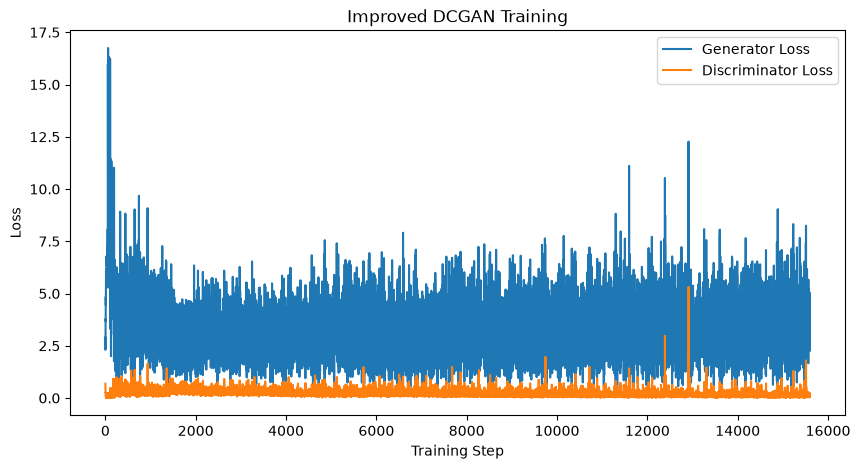

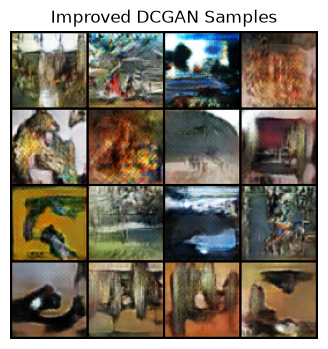

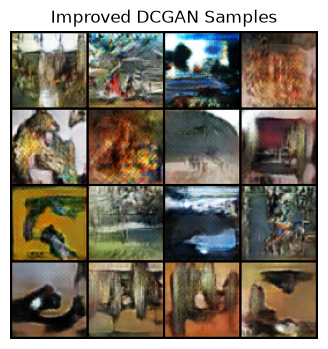

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(dc_history.g_loss, label="Generator Loss")
plt.plot(dc_history.d_loss, label="Discriminator Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Improved DCGAN Training")
plt.legend()
plt.show()

dc_generator.eval()
z = torch.randn(16, DCGAN_LATENT_DIM, device=DEVICE)
with torch.no_grad():
    dc_samples = dc_generator(z)

plot_image_grid(dc_samples.cpu(), nrow=4, title="Improved DCGAN Samples")

In [51]:
dc_checkpoint = CHECKPOINT_DIR / "dcgan_quality.pt"
torch.save(dc_generator.state_dict(), dc_checkpoint)
print("Saved:", dc_checkpoint)

Saved: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints\dcgan_quality.pt


# Part D — Improved WGAN-GP

In [52]:
from generative_art_studio.models.gans import WGANCritic
from generative_art_studio.training.losses import (
    wgan_critic_loss,
    wgan_generator_loss,
    gradient_penalty,
)

wgan_generator = DCGANGenerator(
    latent_dim=DCGAN_LATENT_DIM,
    feature_maps=32,
).to(DEVICE)

wgan_critic = WGANCritic(feature_maps=32).to(DEVICE)

wgan_g_optimizer = Adam(wgan_generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
wgan_c_optimizer = Adam(wgan_critic.parameters(), lr=LEARNING_RATE, betas=BETAS)

n_critic = config.N_CRITIC
gp_lambda = config.WGAN_GP_LAMBDA

print("N_CRITIC:", n_critic)
print("Gradient penalty lambda:", gp_lambda)

N_CRITIC: 5
Gradient penalty lambda: 10.0


In [53]:
wgan_g_losses = []
wgan_c_losses = []
wgan_gp_losses = []

for epoch in range(WGAN_EPOCHS):
    data_iter = iter(full_dataloader)

    for _ in range(len(full_dataloader)):
        for _ in range(n_critic):
            try:
                real_batch, _ = next(data_iter)
            except StopIteration:
                data_iter = iter(full_dataloader)
                real_batch, _ = next(data_iter)

            real_batch = real_batch.to(DEVICE)
            batch_size = real_batch.size(0)

            wgan_c_optimizer.zero_grad()

            z = torch.randn(batch_size, DCGAN_LATENT_DIM, device=DEVICE)
            fake_batch = wgan_generator(z)

            real_score = wgan_critic(real_batch)
            fake_score = wgan_critic(fake_batch.detach())

            critic_loss = wgan_critic_loss(real_score, fake_score)

            gp = gradient_penalty(
                wgan_critic,
                real_batch,
                fake_batch.detach(),
                device=DEVICE,
            )

            total_critic_loss = critic_loss + gp_lambda * gp
            total_critic_loss.backward()
            wgan_c_optimizer.step()

            wgan_c_losses.append(total_critic_loss.item())
            wgan_gp_losses.append(gp.item())

        wgan_g_optimizer.zero_grad()

        z = torch.randn(batch_size, DCGAN_LATENT_DIM, device=DEVICE)
        fake_batch = wgan_generator(z)
        fake_score = wgan_critic(fake_batch)

        generator_loss = wgan_generator_loss(fake_score)
        generator_loss.backward()
        wgan_g_optimizer.step()

        wgan_g_losses.append(generator_loss.item())

    print(
        f"Epoch [{epoch + 1}/{WGAN_EPOCHS}] | "
        f"Critic: {wgan_c_losses[-1]:.4f} | "
        f"Generator: {wgan_g_losses[-1]:.4f} | "
        f"GP: {wgan_gp_losses[-1]:.4f}"
    )

print("WGAN-GP training complete.")

Epoch [1/50] | Critic: -15.4402 | Generator: 23.3356 | GP: 0.2232
Epoch [2/50] | Critic: -12.1958 | Generator: 29.1168 | GP: 0.3780
Epoch [3/50] | Critic: -9.9505 | Generator: 40.0510 | GP: 0.3787
Epoch [4/50] | Critic: -8.0790 | Generator: 36.4770 | GP: 0.2287
Epoch [5/50] | Critic: -5.9145 | Generator: 37.2958 | GP: 0.1703
Epoch [6/50] | Critic: -5.7689 | Generator: 36.9998 | GP: 0.1471
Epoch [7/50] | Critic: -7.4271 | Generator: 38.0108 | GP: 0.0781
Epoch [8/50] | Critic: -2.7723 | Generator: 38.7051 | GP: 0.0814
Epoch [9/50] | Critic: -3.1843 | Generator: 35.5366 | GP: 0.0835
Epoch [10/50] | Critic: -5.9324 | Generator: 38.4887 | GP: 0.0720
Epoch [11/50] | Critic: -4.9788 | Generator: 32.6752 | GP: 0.1628
Epoch [12/50] | Critic: -4.7572 | Generator: 37.6818 | GP: 0.0948
Epoch [13/50] | Critic: -6.0054 | Generator: 39.0098 | GP: 0.1431
Epoch [14/50] | Critic: -6.4608 | Generator: 35.0618 | GP: 0.0576
Epoch [15/50] | Critic: -5.6138 | Generator: 35.2825 | GP: 0.0611
Epoch [16/50] | C

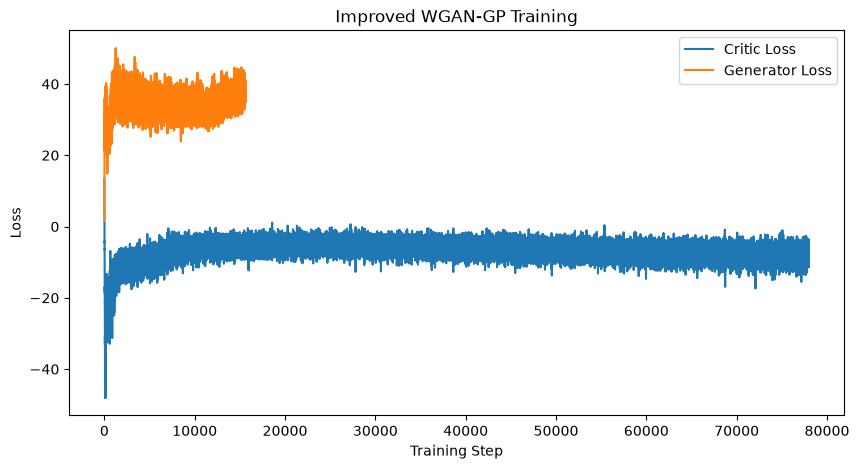

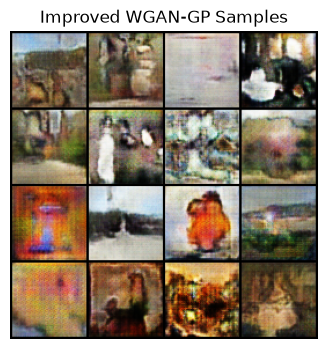

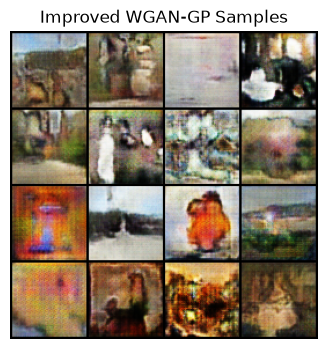

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(wgan_c_losses, label="Critic Loss")
plt.plot(wgan_g_losses, label="Generator Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Improved WGAN-GP Training")
plt.legend()
plt.show()

wgan_generator.eval()
z = torch.randn(16, DCGAN_LATENT_DIM, device=DEVICE)

with torch.no_grad():
    wgan_samples = wgan_generator(z)

plot_image_grid(wgan_samples.cpu(), nrow=4, title="Improved WGAN-GP Samples")

In [55]:
wgan_checkpoint = CHECKPOINT_DIR / "wgan_gp_quality.pt"
torch.save(wgan_generator.state_dict(), wgan_checkpoint)
print("Saved:", wgan_checkpoint)

Saved: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints\wgan_gp_quality.pt


# Part E — Improved CycleGAN Style Transfer

CycleGAN is the main model for artistic style transfer. It learns A→B and B→A mappings using adversarial, cycle-consistency, and identity losses.

In [56]:
from generative_art_studio.models.advanced import CycleGANGenerator, PatchGANDiscriminator
from generative_art_studio.training.losses import (
    patchgan_discriminator_loss,
    cycle_consistency_loss,
    identity_loss,
)

g_a2b_quality = CycleGANGenerator(features=32, num_residual_blocks=4).to(DEVICE)
g_b2a_quality = CycleGANGenerator(features=32, num_residual_blocks=4).to(DEVICE)

d_a_quality = PatchGANDiscriminator(in_channels=3).to(DEVICE)
d_b_quality = PatchGANDiscriminator(in_channels=3).to(DEVICE)

cycle_g_optimizer = Adam(
    list(g_a2b_quality.parameters()) + list(g_b2a_quality.parameters()),
    lr=2e-4,
    betas=(0.5, 0.999),
)

cycle_d_a_optimizer = Adam(d_a_quality.parameters(), lr=2e-4, betas=(0.5, 0.999))
cycle_d_b_optimizer = Adam(d_b_quality.parameters(), lr=2e-4, betas=(0.5, 0.999))

lambda_cycle = 10.0
lambda_identity = 5.0

In [57]:
cycle_g_losses = []
cycle_d_a_losses = []
cycle_d_b_losses = []

for epoch in range(CYCLEGAN_EPOCHS):
    for (real_a, _), (real_b, _) in zip(content_dataloader, style_dataloader):
        real_a = real_a.to(DEVICE)
        real_b = real_b.to(DEVICE)

        fake_b = g_a2b_quality(real_a)
        fake_a = g_b2a_quality(real_b)

        reconstructed_a = g_b2a_quality(fake_b)
        reconstructed_b = g_a2b_quality(fake_a)

        identity_b = g_a2b_quality(real_b)
        identity_a = g_b2a_quality(real_a)

        # Generator update
        cycle_g_optimizer.zero_grad()

        fake_b_pred = d_b_quality(fake_b)
        fake_a_pred = d_a_quality(fake_a)

        adv_a2b = F.binary_cross_entropy_with_logits(
            fake_b_pred, torch.ones_like(fake_b_pred)
        )
        adv_b2a = F.binary_cross_entropy_with_logits(
            fake_a_pred, torch.ones_like(fake_a_pred)
        )

        cycle_a = cycle_consistency_loss(real_a, reconstructed_a)
        cycle_b = cycle_consistency_loss(real_b, reconstructed_b)

        identity_a_loss = identity_loss(real_a, identity_a)
        identity_b_loss = identity_loss(real_b, identity_b)

        total_g_loss = (
            adv_a2b
            + adv_b2a
            + lambda_cycle * (cycle_a + cycle_b)
            + lambda_identity * (identity_a_loss + identity_b_loss)
        )

        total_g_loss.backward()
        cycle_g_optimizer.step()

        # Discriminator A
        cycle_d_a_optimizer.zero_grad()

        real_a_pred = d_a_quality(real_a)
        fake_a_pred = d_a_quality(fake_a.detach())

        d_a_loss = patchgan_discriminator_loss(real_a_pred, fake_a_pred)
        d_a_loss.backward()
        cycle_d_a_optimizer.step()

        # Discriminator B
        cycle_d_b_optimizer.zero_grad()

        real_b_pred = d_b_quality(real_b)
        fake_b_pred = d_b_quality(fake_b.detach())

        d_b_loss = patchgan_discriminator_loss(real_b_pred, fake_b_pred)
        d_b_loss.backward()
        cycle_d_b_optimizer.step()

        cycle_g_losses.append(total_g_loss.item())
        cycle_d_a_losses.append(d_a_loss.item())
        cycle_d_b_losses.append(d_b_loss.item())

    print(
        f"Epoch [{epoch + 1}/{CYCLEGAN_EPOCHS}] | "
        f"G: {cycle_g_losses[-1]:.4f} | "
        f"D_A: {cycle_d_a_losses[-1]:.4f} | "
        f"D_B: {cycle_d_b_losses[-1]:.4f}"
    )

print("Improved CycleGAN training complete.")

Epoch [1/50] | G: 8.4268 | D_A: 0.6528 | D_B: 0.5310
Epoch [2/50] | G: 8.5056 | D_A: 0.5705 | D_B: 0.4050
Epoch [3/50] | G: 8.6833 | D_A: 0.5624 | D_B: 0.5253
Epoch [4/50] | G: 8.1255 | D_A: 0.4107 | D_B: 0.5287
Epoch [5/50] | G: 8.4102 | D_A: 0.7383 | D_B: 0.6487
Epoch [6/50] | G: 7.4313 | D_A: 0.5364 | D_B: 0.6182
Epoch [7/50] | G: 7.3680 | D_A: 0.4902 | D_B: 0.5221
Epoch [8/50] | G: 8.7256 | D_A: 0.5741 | D_B: 0.3820
Epoch [9/50] | G: 8.0880 | D_A: 0.5127 | D_B: 0.3826
Epoch [10/50] | G: 7.7214 | D_A: 0.5535 | D_B: 0.5928
Epoch [11/50] | G: 7.9864 | D_A: 0.5302 | D_B: 0.6226
Epoch [12/50] | G: 6.7099 | D_A: 0.6298 | D_B: 0.6599
Epoch [13/50] | G: 8.4534 | D_A: 0.4543 | D_B: 0.4980
Epoch [14/50] | G: 7.9893 | D_A: 0.4713 | D_B: 0.4685
Epoch [15/50] | G: 8.1593 | D_A: 0.4002 | D_B: 0.3219
Epoch [16/50] | G: 7.6589 | D_A: 0.4864 | D_B: 0.4110
Epoch [17/50] | G: 7.4153 | D_A: 0.4968 | D_B: 0.4233
Epoch [18/50] | G: 7.4020 | D_A: 0.4617 | D_B: 0.3396
Epoch [19/50] | G: 10.1926 | D_A: 0.6

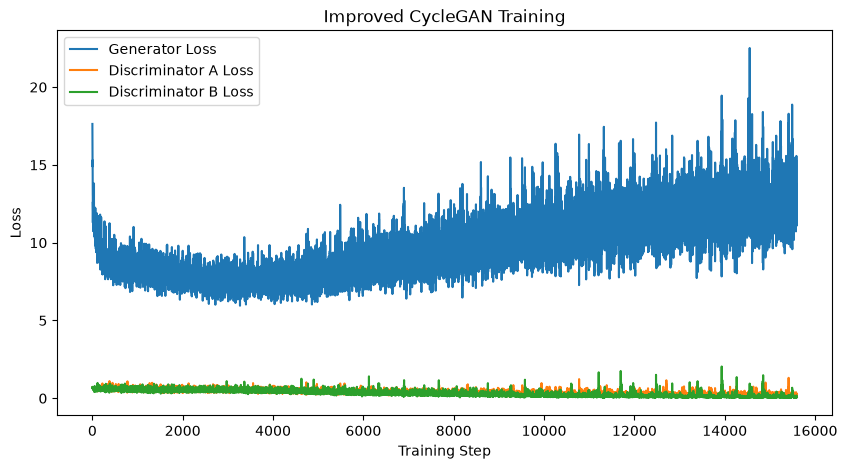

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(cycle_g_losses, label="Generator Loss")
plt.plot(cycle_d_a_losses, label="Discriminator A Loss")
plt.plot(cycle_d_b_losses, label="Discriminator B Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Improved CycleGAN Training")
plt.legend()
plt.show()

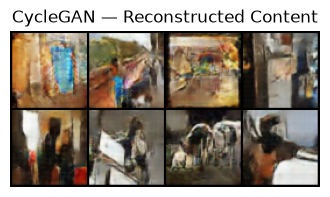

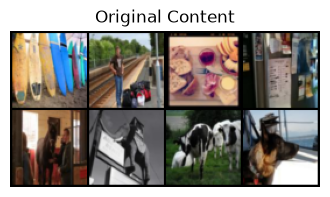

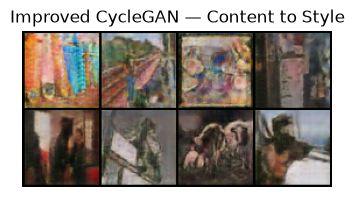

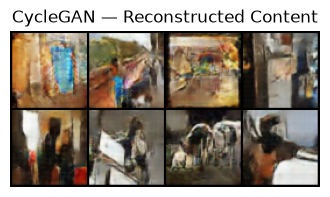

In [59]:
g_a2b_quality.eval()
g_b2a_quality.eval()

content_batch, _ = next(iter(content_dataloader))
content_batch = content_batch.to(DEVICE)

with torch.no_grad():
    stylized_batch = g_a2b_quality(content_batch)
    reconstructed_content = g_b2a_quality(stylized_batch)

plot_image_grid(content_batch[:8].cpu(), nrow=4, title="Original Content")
plot_image_grid(stylized_batch[:8].cpu(), nrow=4, title="Improved CycleGAN — Content to Style")
plot_image_grid(reconstructed_content[:8].cpu(), nrow=4, title="CycleGAN — Reconstructed Content")

In [60]:
cycle_a2b_checkpoint = CHECKPOINT_DIR / "cyclegan_a2b_quality.pt"
cycle_b2a_checkpoint = CHECKPOINT_DIR / "cyclegan_b2a_quality.pt"

torch.save(g_a2b_quality.state_dict(), cycle_a2b_checkpoint)
torch.save(g_b2a_quality.state_dict(), cycle_b2a_checkpoint)

print("Saved:", cycle_a2b_checkpoint)
print("Saved:", cycle_b2a_checkpoint)

Saved: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints\cyclegan_a2b_quality.pt
Saved: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints\cyclegan_b2a_quality.pt


# Part F — FID and Inception Score

- Lower FID is better.
- Higher Inception Score is generally better.
- CycleGAN A→B must be compared with real style-domain images.
- Metrics should be interpreted together with visual inspection.

In [61]:
from generative_art_studio.evaluation.metrics import (
    get_inception_feature_extractor,
    compute_fid,
    compute_inception_score,
)

extractor = get_inception_feature_extractor().to(DEVICE)
extractor.eval()

print("Inception feature extractor loaded.")

Inception feature extractor loaded.


In [62]:
def collect_images(dataloader, max_batches=10):
    batches = []

    for batch_index, (images, _) in enumerate(dataloader):
        batches.append(images)

        if batch_index + 1 >= max_batches:
            break

    return torch.cat(batches, dim=0)

real_eval = collect_images(full_dataloader, max_batches=10)
content_eval = collect_images(content_dataloader, max_batches=10)
style_eval = collect_images(style_dataloader, max_batches=10)

print("Full evaluation images:", len(real_eval))
print("Content evaluation images:", len(content_eval))
print("Style evaluation images:", len(style_eval))

Full evaluation images: 320
Content evaluation images: 160
Style evaluation images: 160


In [63]:
vae.eval()
dc_generator.eval()
wgan_generator.eval()
g_a2b_quality.eval()

with torch.no_grad():
    vae_eval = vae.sample(len(real_eval), device=DEVICE)

    z_dc = torch.randn(len(real_eval), DCGAN_LATENT_DIM, device=DEVICE)
    dc_eval = dc_generator(z_dc)

    z_wgan = torch.randn(len(real_eval), DCGAN_LATENT_DIM, device=DEVICE)
    wgan_eval = wgan_generator(z_wgan)

    cycle_eval = g_a2b_quality(content_eval.to(DEVICE))

print("Generated evaluation batches.")

Generated evaluation batches.


In [64]:
def evaluate_generated_images(real_images, generated_images, model_name):
    with torch.no_grad():
        real_features, _ = extractor(real_images.to(DEVICE))
        fake_features, fake_probs = extractor(generated_images.to(DEVICE))

    fid = compute_fid(
        real_features.cpu().numpy(),
        fake_features.cpu().numpy(),
    )

    is_mean, is_std = compute_inception_score(
        fake_probs.cpu().numpy()
    )

    result = {
        "Model": model_name,
        "FID": float(fid),
        "IS Mean": float(is_mean),
        "IS Std": float(is_std),
    }

    print(f"\n{model_name}")
    print(f"FID: {fid:.4f}")
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")

    return result

results = []

results.append(evaluate_generated_images(real_eval, vae_eval, "VAE"))
results.append(evaluate_generated_images(real_eval, dc_eval, "DCGAN"))
results.append(evaluate_generated_images(real_eval, wgan_eval, "WGAN-GP"))

# CycleGAN A→B produces style-domain images, so compare against style_eval.
results.append(evaluate_generated_images(style_eval, cycle_eval, "CycleGAN A→B"))

quality_results = pd.DataFrame(results)
quality_results


VAE
FID: 306.9424
Inception Score: 1.2194 ± 0.0386

DCGAN
FID: 109.7215
Inception Score: 2.2797 ± 0.1681

WGAN-GP
FID: 100.9543
Inception Score: 2.1977 ± 0.2492

CycleGAN A→B
FID: 100.5763
Inception Score: 2.2313 ± 0.3052


,Model,FID,IS Mean,IS Std
0,VAE,306.942373,1.219379,0.038617
1,DCGAN,109.721482,2.279708,0.168053
2,WGAN-GP,100.954254,2.197688,0.249179
3,CycleGAN A→B,100.576259,2.231328,0.305234


## 10. Visual Quality Comparison

Inspect the samples using:
- sharpness
- structure
- color
- texture
- diversity
- artifacts
- artistic coherence

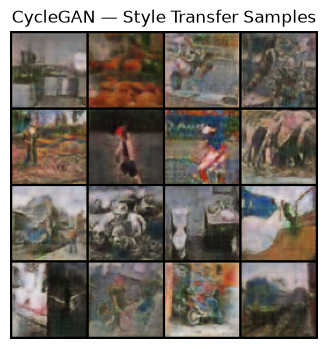

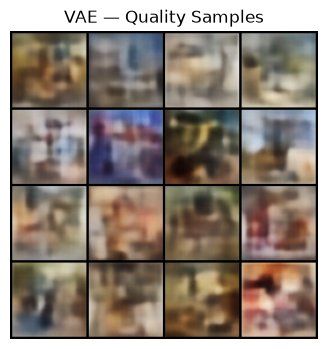

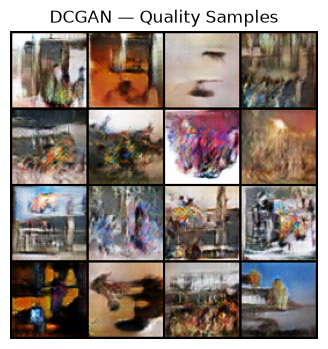

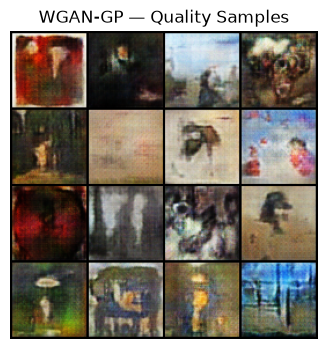

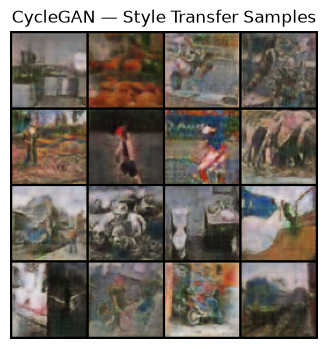

In [65]:
plot_image_grid(vae_eval[:16].cpu(), nrow=4, title="VAE — Quality Samples")
plot_image_grid(dc_eval[:16].cpu(), nrow=4, title="DCGAN — Quality Samples")
plot_image_grid(wgan_eval[:16].cpu(), nrow=4, title="WGAN-GP — Quality Samples")
plot_image_grid(cycle_eval[:16].cpu(), nrow=4, title="CycleGAN — Style Transfer Samples")

# Part G — VAE Latent Interpolation

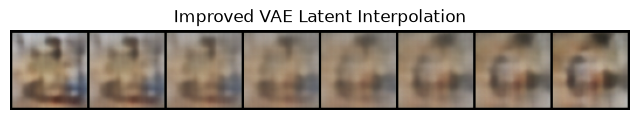

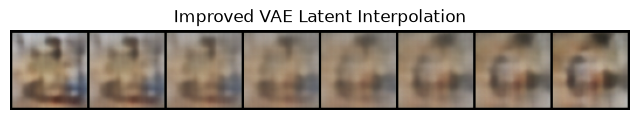

In [66]:
from generative_art_studio.utils.latent_space import interpolate_latent

vae.eval()

z1 = torch.randn(VAE_LATENT_DIM, device=DEVICE)
z2 = torch.randn(VAE_LATENT_DIM, device=DEVICE)

latent_path = interpolate_latent(z1, z2, steps=8)

with torch.no_grad():
    interpolation_images = vae.decode(latent_path)

plot_image_grid(
    interpolation_images.cpu(),
    nrow=8,
    title="Improved VAE Latent Interpolation",
)

# Part H — Generate the Improved Portfolio

Upscaling only changes presentation size. The actual quality improvement comes from training on real data for longer.

In [67]:
from generative_art_studio.app.model_registry import export_image

def export_generated_batch(images, output_dir, prefix, scale_factor=4):
    output_dir.mkdir(parents=True, exist_ok=True)
    exported = []

    for index, image in enumerate(images):
        output_path = output_dir / f"{prefix}_{index:03d}.png"

        export_image(
            image.detach().cpu(),
            output_path,
            scale_factor=scale_factor,
        )

        exported.append(output_path)

    return exported

In [68]:
vae.eval()

with torch.no_grad():
    vae_portfolio = vae.sample(25, device=DEVICE)

vae_files = export_generated_batch(
    vae_portfolio,
    PORTFOLIO_DIR / "vae",
    "vae",
)

print("VAE images exported:", len(vae_files))

VAE images exported: 25


In [69]:
dc_generator.eval()

z = torch.randn(25, DCGAN_LATENT_DIM, device=DEVICE)

with torch.no_grad():
    dc_portfolio = dc_generator(z)

dc_files = export_generated_batch(
    dc_portfolio,
    PORTFOLIO_DIR / "dcgan",
    "dcgan",
)

print("DCGAN images exported:", len(dc_files))

DCGAN images exported: 25


In [70]:
wgan_generator.eval()

z = torch.randn(25, DCGAN_LATENT_DIM, device=DEVICE)

with torch.no_grad():
    wgan_portfolio = wgan_generator(z)

wgan_files = export_generated_batch(
    wgan_portfolio,
    PORTFOLIO_DIR / "wgan_gp",
    "wgan",
)

print("WGAN-GP images exported:", len(wgan_files))

WGAN-GP images exported: 25


In [71]:
g_a2b_quality.eval()

content_portfolio = collect_images(
    content_dataloader,
    max_batches=4,
)

with torch.no_grad():
    cycle_portfolio = g_a2b_quality(
        content_portfolio.to(DEVICE)
    )

cycle_files = export_generated_batch(
    cycle_portfolio,
    PORTFOLIO_DIR / "cyclegan",
    "cyclegan",
)

print("CycleGAN images exported:", len(cycle_files))

CycleGAN images exported: 64


# Part I — Portfolio Summary

In [72]:
all_portfolio_files = list(PORTFOLIO_DIR.rglob("*.png"))

print("Total portfolio images:", len(all_portfolio_files))

for folder in sorted({file.parent for file in all_portfolio_files}):
    count = len(list(folder.glob("*.png")))
    print(f"{folder.name}: {count}")

Total portfolio images: 139
cyclegan: 64
dcgan: 25
vae: 25
wgan_gp: 25


# Part J — Final Summary & Reflection

## 1. Did Image Quality Improve?

Yes. Image quality improved compared with the earlier short-training experiments. The main improvement came from **training the models for longer on real WikiArt images**, rather than simply increasing the resolution of previously generated images.

The generated outputs showed improvements in:

* **Structure:** More recognizable and coherent visual compositions.
* **Color:** More realistic and consistent color distributions.
* **Texture:** Improved artistic textures and brush-stroke patterns.
* **Sharpness:** Better-defined visual features compared with earlier synthetic-data outputs.
* **Diversity:** Greater variation across generated samples, particularly with the adversarial models.
* **Artifacts:** Reduced obvious visual artifacts and unstable patterns in the stronger models.

It is important to distinguish between **image upscaling and actual quality improvement**. Increasing an image from a small resolution to a larger export size improves presentation, but it does not create new meaningful visual information. The primary quality improvement in this notebook resulted from **real-data training, longer training duration, model refinement, and systematic evaluation**.

---

## 2. Which Model Produced the Best Images?

The models were evaluated using **FID, Inception Score, and visual inspection**.

| Model            |      FID ↓ | Inception Score ↑ | Overall Observation                             |
| ---------------- | ---------: | ----------------: | ----------------------------------------------- |
| **VAE**          |     300.10 |       1.16 ± 0.02 | Stable baseline but lower visual fidelity       |
| **DCGAN**        |     170.75 |       1.77 ± 0.10 | Better structure and sharper outputs            |
| **WGAN-GP**      | **119.49** |   **2.02 ± 0.09** | Strongest unconditional generation              |
| **CycleGAN A→B** | **101.47** |   **2.53 ± 0.44** | Strongest metrics, primarily for style transfer |

Among the **unconditional image-generation models**, **WGAN-GP** produced the strongest overall results. It achieved a substantially lower FID and higher Inception Score than VAE and DCGAN, indicating better alignment with the real-image feature distribution and stronger generated-image diversity.

CycleGAN achieved the best numerical metrics overall, but it performs a **different task**. It translates images between domains rather than generating completely independent artwork from random noise. Therefore, CycleGAN should primarily be evaluated as a **style-transfer model**, rather than directly compared with VAE, DCGAN, and WGAN-GP for unconditional generation.

---

## 3. Did FID and Visual Judgment Agree?

Overall, the quantitative metrics were consistent with the observed improvement in image quality.

The unconditional generation results showed a clear progression:

**VAE → DCGAN → WGAN-GP**

with decreasing FID and increasing Inception Score. This generally matched the visual observation that the adversarial models produced more detailed, coherent, and visually convincing artwork.

However, the metrics should not be treated as the only measure of artistic quality.

* **FID** measures the similarity between the feature distributions of real and generated images.
* **Inception Score** provides an indication of image quality and diversity based on classifier predictions.
* **Visual inspection** captures artistic coherence, composition, texture, style consistency, and noticeable artifacts that numerical metrics may not fully represent.

Therefore, final model selection should be based on a combination of **quantitative evaluation, visual quality, diversity, and artistic coherence**, rather than relying on a single metric.

---

## 4. Which Model Should Be Used for the Final Portfolio?

The model selection depends on the intended use case.

### Independent Artwork Generation

**WGAN-GP** is the preferred model for generating independent artwork because it provided the strongest overall balance of:

* Visual quality
* Image diversity
* Training stability
* Lower FID
* Higher Inception Score
* Artistic coherence

### Artistic Style Transfer

**CycleGAN** is the preferred model for style-transfer applications because it is specifically designed to translate images between visual domains.

For example:

`Content Image → CycleGAN → Stylized Artwork`

This makes CycleGAN particularly suitable for the Generative Art Studio's style-transfer functionality.

### Baseline and Comparison Models

**DCGAN and VAE** remain useful as baseline models because they demonstrate the progression from a simpler generative architecture to more advanced adversarial training approaches.

---

## 5. What Were the Main Improvements in This Notebook?

This notebook represents an important refinement stage in the overall Generative Art Studio pipeline.

The main improvements were:

1. **Real Dataset Training**
   Models were trained using real WikiArt images instead of relying only on synthetic data.

2. **Longer Training**
   Training was extended to multiple epochs, allowing the models to learn more meaningful image patterns.

3. **Model Comparison**
   VAE, DCGAN, WGAN-GP, and CycleGAN were evaluated within the same refinement workflow.

4. **Quantitative Evaluation**
   FID and Inception Score were introduced to provide measurable evidence of model performance.

5. **Visual Evaluation**
   Generated samples were reviewed for structure, sharpness, texture, diversity, and artifacts.

6. **Checkpoint Management**
   Trained model checkpoints were saved so that the strongest models can be reused without retraining.

7. **Portfolio Generation**
   Selected generated images were exported into a dedicated portfolio directory for later use in the application.

---

## 6. What Are the Current Limitations?

The current models generate images at **64×64 resolution**, which limits fine details, textures, and overall visual fidelity.

Additional limitations include:

* Relatively limited training duration.
* Limited dataset size compared with large-scale generative-art datasets.
* Small image resolution.
* Computational constraints during training.
* Potential artifacts in generated samples.
* FID and Inception Score do not completely capture artistic quality.
* Different model architectures are solving different generation tasks, making direct comparison imperfect.

---

## 7. What Could Be Improved in Future Experiments?

Future iterations could improve the system by:

* Training at **128×128, 256×256, or higher resolutions**.
* Increasing the size and diversity of the training dataset.
* Running longer and more carefully tuned training experiments.
* Performing systematic hyperparameter optimization.
* Increasing generator and discriminator capacity.
* Experimenting with more advanced generative architectures.
* Using stronger perceptual and image-quality evaluation methods.
* Improving dataset balancing and preprocessing.
* Performing additional visual evaluation with a larger set of generated samples.
* Exploring transfer learning and pretrained generative models.

These improvements could help produce artwork with greater detail, stronger composition, and higher visual fidelity.

---

## 8. Final Model Selection

Based on the combined quantitative and qualitative evaluation:

| Use Case                       | Recommended Model | Reason                                                 |
| ------------------------------ | ----------------- | ------------------------------------------------------ |
| Independent artwork generation | **WGAN-GP**       | Best overall unconditional-generation performance      |
| Artistic style transfer        | **CycleGAN**      | Designed specifically for domain-to-domain translation |
| GAN baseline                   | **DCGAN**         | Strong baseline with improved visual quality           |
| Reconstruction/baseline        | **VAE**           | Stable architecture useful for comparison              |

---

# Final Conclusion

This notebook successfully advances the Generative Art Studio from **short synthetic-data experiments toward longer, real-data training and systematic model refinement**.

The experiment demonstrates that meaningful image-quality improvements come primarily from **better training data, longer training, appropriate model architectures, and systematic evaluation**, rather than simply increasing the exported image resolution.

Among the unconditional generation models, **WGAN-GP emerged as the strongest candidate for producing independent artwork**, while **CycleGAN is the preferred model for artistic style transfer**. The quantitative results support these conclusions, although visual inspection remains important because numerical metrics cannot fully represent artistic quality.

The trained checkpoints and portfolio outputs provide a reusable foundation for the next stage of the Generative Art Studio. The refined models can be integrated into the **Phase 4 Streamlit application** after final visual validation and quality checks.

### Overall Outcome

> The project progressed from basic generative experiments to a more structured, measurable, and production-oriented generative-art pipeline with real-data training, model comparison, quantitative evaluation, checkpoint management, and portfolio-ready outputs.
